<a href="https://colab.research.google.com/github/laiimour/cqv-hac-mopso/blob/main/01_Laboratorio_CQV_Basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane
!pip install pennylane-qiskit
!pip install pennylane-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 43.7 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB

In [21]:
import pennylane as qp
from pennylane import numpy as np
from pennylane.optimize import (
    NesterovMomentumOptimizer,
    GradientDescentOptimizer,
    AdamOptimizer
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [3]:
# 1. Configuração do Dispositivo Quântico
num_qubits = 2
dev = qp.device("default.qubit", wires=num_qubits)

📌 **TIPO DE EMBEDDING (CODIFICAÇÃO)**: No Bloco 2 (definição do circuito), você pode alterar a forma como os dados clássicos são convertidos para o estado quântico, substituindo o qp.AmplitudeEmbedding por outras abordagens (como qp.AngleEmbedding).

Diferentes métodos de embedding exigem quantidades distintas de qubits e alteram a forma como a informação é distribuída no espaço de Hilbert, impactando diretamente a facilidade com que o circuito consegue separar as classes.

In [22]:
# 2. Definição do Circuito e do Ansatz
def layer(layer_weights):
    for wire in range(num_qubits):
        qp.Rot(*layer_weights[wire], wires=wire)
    qp.CNOT(wires=[0, 1])

@qp.qnode(dev)
def circuit(weights, x):
    # Codificação dos dados clássicos no estado quântico
    qp.AmplitudeEmbedding(x, wires=range(num_qubits), normalize=True)

    # Aplicação das camadas parametrizadas (Ansatz)
    for layer_weights in weights:
        layer(layer_weights)

    return qp.expval(qp.PauliZ(0))

def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias

In [5]:
# 3. Funções de Custo e Métricas
def square_loss(labels, predictions):
    return np.mean((labels - qp.math.stack(predictions)) ** 2)

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    return acc / len(labels)

def cost(weights, bias, X, Y):
    predictions = [variational_classifier(weights, bias, x) for x in X]
    return square_loss(Y, predictions)

In [6]:
# 4. Carregamento e pré-processamento dos Dados
data = np.loadtxt("https://blog-assets.cloud.pennylane.ai/demos/tutorial_variational_classifier/main/_assets/static/demonstration_assets/variational_classifier/data/parity_train.txt", dtype=int)
X = np.array(data[:, :-1])
Y = np.array(data[:, -1])
Y = Y * 2 - 1  # Ajusta os rótulos de {0, 1} para {-1, 1}[cite: 7]

In [7]:
# 5. Divisão em Treino (60%), Validação (20%) e Teste (20%)

# Primeiro corte: Separa 20% para Teste final
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

# Segundo corte: Divide o restante em Treino (60% do total) e Validação (20% do total)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25, random_state=42
)

📌 **PROFUNDIDADE DO CIRCUITO**: No **Bloco 6**, a seguir, você pode alterar o número de camadas (num_layers), para valores menores ou maiores e observar como a capacidade expressiva do circuito muda.

Com poucas camadas, o modelo pode ter underfitting. Com muitas camadas, o circuito pode sofrer com o fenômeno de barren plateaus (platôs estéreis) ou overfitting.

📌 **TAXA DE APRENDIZAGEM DO OTIMIZADOR**: Você pode alterar a taxa de aprendizado do otimizador (NesterovMomentumOptimizer), modificando o valor (por exemplo, de 0.01 para 0.1 ou 0.001).

Com uma taxa muito alta, os pesos podem oscilar drasticamente e o custo não convergir. Com uma taxa muito baixa, o treinamento se torna extremamente lento e pode estacionar em mínimos locais.

📌 **TAMANHO DO LOTE (BATCH SIZE)**: Você pode alterar o tamanho do lote (batch_size = 5), testando valores menores (como 1 para gradiente estocástico) ou maiores (como o tamanho total do treino para aprendizado em lote completo).

Lotes menores trazem mais ruído nas atualizações, mas ajudam a escapar de mínimos locais. Lotes maiores geram curvas de aprendizado mais suaves, porém consomem mais recursos e podem estabilizar cedo demais.

📌 **OTIMIZADOR CLÁSSICO**: Você também pode alterar o algoritmo de otimização trocando o NesterovMomentumOptimizer por outras opções (como o AdamOptimizer ou o GradientDescentOptimizer).

Otimizadores como o Adam ajustam a taxa de aprendizado dinamicamente ao longo das iterações, enquanto o GradientDescent puro pode exigir ajustes manuais mais rigorosos para evitar que o treinamento estacione em mínimos locais ou platôs estéreis.



In [24]:
# 6. Inicialização dos Pesos e Otimizador
np.random.seed(0)
num_layers = 2
weights_init = 0.01 * np.random.randn(num_layers, 4, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)

opt = NesterovMomentumOptimizer(0.1)
batch_size = 5

weights = weights_init
bias = bias_init

↪ **CRITÉRIO DE PARADA (PATIENCE)**: No  **Bloco 7**, a seguir, você pode alterar o nível de patience do early stopping (patience = 8), definindo valores menores (como 2) ou maiores (como 20).

Um patience muito curto pode interromper o treinamento antes que o modelo atinja seu potencial máximo. Já um muito longo pode desperdiçar tempo de processamento e levar ao overfitting se o erro de validação voltar a subir.

In [9]:
# 7. Parâmetros do Critério de Paragem (Early Stopping)

patience = 15                    # Número de iterações consecutivas sem melhoria
patience_counter = 0             # Contador de paciência
best_cost_val = float("inf")     # Inicializa o melhor custo com infinito
best_weights = None              # Guarda os melhores pesos encontrados
best_bias = None                 # Guarda o melhor bias encontrado

In [10]:
# 8. Ciclo de Treino com Early Stopping

for it in range(100):
    # Atualização dos pesos usando lotes aleatórios do conjunto de TREINO
    batch_index = np.random.randint(0, len(X_train), (batch_size,))
    X_batch = X_train[batch_index]
    Y_batch = Y_train[batch_index]
    weights, bias = opt.step(cost, weights, bias, X=X_batch, Y=Y_batch)

    # Avaliação contínua no conjunto de VALIDAÇÃO (sem atualizar os pesos)
    cost_val = cost(weights, bias, X_val, Y_val)

    # Verificação da condição de paragem
    if cost_val < best_cost_val - 1e-4:
        best_cost_val = cost_val
        best_weights = weights.copy()
        best_bias = bias
        patience_counter = 0
    else:
        patience_counter += 1

    # Cálculo da acuidade no treino para monitorização
    predictions_train = [np.sign(variational_classifier(weights, bias, x)) for x in X_train]
    acc_train = accuracy(Y_train, predictions_train)

    print(f"Iter: {it+1:4d} | Cost Val: {cost_val:0.7f} | Acc Treino: {acc_train:0.7f}")

    # Interrompe o treino se atingir o limite de paciência
    if patience_counter >= patience:
        print(f"\n[Critério de Parada] Treino interrompido na iteração {it+1}!")
        print(f"Melhor custo registado na validação: {best_cost_val:0.7f}")
        break

Iter:    1 | Cost Val: 2.4631916 | Acc Treino: 0.3333333
Iter:    2 | Cost Val: 2.5314197 | Acc Treino: 0.3333333
Iter:    3 | Cost Val: 2.5715748 | Acc Treino: 0.3333333
Iter:    4 | Cost Val: 2.6209012 | Acc Treino: 0.6666667
Iter:    5 | Cost Val: 2.7239367 | Acc Treino: 0.8333333
Iter:    6 | Cost Val: 2.8316273 | Acc Treino: 0.8333333
Iter:    7 | Cost Val: 2.8228363 | Acc Treino: 0.8333333
Iter:    8 | Cost Val: 2.5262827 | Acc Treino: 0.8333333
Iter:    9 | Cost Val: 2.4216110 | Acc Treino: 0.8333333
Iter:   10 | Cost Val: 2.1855877 | Acc Treino: 0.8333333
Iter:   11 | Cost Val: 1.8644524 | Acc Treino: 0.8333333
Iter:   12 | Cost Val: 1.6404907 | Acc Treino: 0.8333333
Iter:   13 | Cost Val: 1.5180740 | Acc Treino: 0.8333333
Iter:   14 | Cost Val: 1.4641526 | Acc Treino: 0.8333333
Iter:   15 | Cost Val: 1.5157017 | Acc Treino: 1.0000000
Iter:   16 | Cost Val: 1.6262591 | Acc Treino: 1.0000000
Iter:   17 | Cost Val: 1.6207104 | Acc Treino: 1.0000000
Iter:   18 | Cost Val: 1.576257

In [11]:
# 9. Avaliação Final no Conjunto de TESTE
# Utilizam-se os melhores pesos e bias guardados durante o treino
predictions_test = [np.sign(variational_classifier(best_weights, best_bias, x)) for x in X_test]
acc_test = accuracy(Y_test, predictions_test)
cost_test = cost(best_weights, best_bias, X_test, Y_test)

print("-" * 50)
print(f"Resultado no Conjunto de Teste:")
print(f"Custo de Teste: {cost_test:0.7f} | Acurácia de Teste: {acc_test * 100:.2f}%")
print("-" * 50)

--------------------------------------------------
Resultado no Conjunto de Teste:
Custo de Teste: 1.5562509 | Acurácia de Teste: 0.00%
--------------------------------------------------


In [12]:
### Classificação da Íris + PCA com as 4 FEATURES

In [14]:
# 1. Definição do Circuito e do Ansatz

def layer(layer_weights):
    for wire in range(2):
        qp.Rot(*layer_weights[wire], wires=wire)
    qp.CNOT(wires=[0, 1])

@qp.qnode(dev)
def circuit(weights, x):
  # AmplitudeEmbedding com as 4 features diretamente
    qp.AmplitudeEmbedding(x, wires=range(2), normalize=True) #qp.AmplitudeEmbedding(x, wires=range(2))

    for layer_weights in weights:
        layer(layer_weights)

    return qp.expval(qp.PauliZ(0))

def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias

def square_loss(labels, predictions):
    return np.mean((labels - qp.math.stack(predictions)) ** 2)

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def cost(weights, bias, X, Y):
    predictions = [variational_classifier(weights, bias, x) for x in X]
    return square_loss(Y, predictions)

In [15]:
# 2. Carregamento e Pré-processamento dos Dados (Iris)

data = np.loadtxt("https://blog-assets.cloud.pennylane.ai/demos/tutorial_variational_classifier/main/_assets/static/demonstration_assets/variational_classifier/data/iris_classes1and2_scaled.txt")
X = data[:, 0:4] #todas as 4 features (sem padding)
print(f"First X sample (original)  : {X[0]}")

# Pega todas as 4 colunas de características (Questão 2)
X = data[:, :-1]
Y = data[:, -1]   # Rótulos {-1, 1}

# Normalização direta das 4 features para Amplitude Embedding
normalization = np.sqrt(np.sum(X**2, axis=-1, keepdims=True))
X_norm = X / normalization

First X sample (original)  : [0.4  0.75 0.2  0.05]


In [16]:
# 3. Divisão em Treino (60%), Validação (20%) e Teste (20%)

# Separa 20% para teste final
X_temp, feats_test, Y_temp, Y_test = train_test_split(
    X_norm, Y, test_size=0.20, random_state=42, stratify=Y
)

# Divide o restante em treino (60%) e validação (20%)
feats_train, feats_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25, random_state=42, stratify=Y_temp
)


In [17]:
# 4. Inicialização de Pesos e Otimizador

np.random.seed(0)
num_qubits = 2
num_layers = 6

weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)

opt = NesterovMomentumOptimizer(0.01)
batch_size = 5

weights = weights_init
bias = bias_init

# Parâmetros do Critério de Parada
patience = 8
patience_counter = 0
best_cost_val = float("inf")
best_weights = None
best_bias = None

In [18]:
# 5. Loop de Treinamento com Critério de Parada

for it in range(100):
    # Atualiza pesos usando lotes do conjunto de TREINO
    batch_index = np.random.randint(0, len(feats_train), (batch_size,))
    feats_train_batch = feats_train[batch_index]
    Y_train_batch = Y_train[batch_index]

    weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

    # Avalia o custo no conjunto de VALIDAÇÃO para o critério de parada
    cost_val = cost(weights, bias, feats_val, Y_val)

    # Verifica se houve melhora no erro de validação
    if cost_val < best_cost_val - 1e-4:
        best_cost_val = cost_val
        best_weights = weights.copy() # atinge um novo recorde de menor custo de validação e salva uma cópia independente
        best_bias = bias
        patience_counter = 0
    else:
        patience_counter += 1

    # Monitoramento
    if (it + 1) % 2 == 0:
        pred_train = [np.sign(variational_classifier(weights, bias, x)) for x in feats_train]
        pred_val = [np.sign(variational_classifier(weights, bias, x)) for x in feats_val]
        acc_train = accuracy(Y_train, pred_train)
        acc_val = accuracy(Y_val, pred_val)

        print(
            f"Iter: {it + 1:3d} | Cost Val: {cost_val:0.7f} | "
            f"Acc train: {acc_train:0.7f} | Acc validation: {acc_val:0.7f}"
        )

    # Dispara a interrupção se a paciência esgotar
    if patience_counter >= patience:
        print(f"\n[Critério de Parada] Treino interrompido na iteração {it+1}!")
        print(f"Melhor custo registrado na validação: {best_cost_val:0.7f}")
        break

/usr/local/lib/python3.13/dist-packages/autograd/numpy/numpy_wrapper.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
  return A.astype(dtype, order, casting, subok, copy)


Iter:   2 | Cost Val: 2.8536709 | Acc train: 0.0166667 | Acc validation: 0.0000000
Iter:   4 | Cost Val: 2.8031251 | Acc train: 0.0166667 | Acc validation: 0.0000000
Iter:   6 | Cost Val: 2.6751818 | Acc train: 0.0166667 | Acc validation: 0.0000000
Iter:   8 | Cost Val: 2.3667115 | Acc train: 0.0833333 | Acc validation: 0.0500000
Iter:  10 | Cost Val: 1.7062502 | Acc train: 0.5000000 | Acc validation: 0.4500000
Iter:  12 | Cost Val: 0.7942940 | Acc train: 0.5166667 | Acc validation: 0.5000000
Iter:  14 | Cost Val: 0.1461966 | Acc train: 0.9833333 | Acc validation: 1.0000000
Iter:  16 | Cost Val: 0.1737954 | Acc train: 1.0000000 | Acc validation: 1.0000000
Iter:  18 | Cost Val: 0.3506714 | Acc train: 0.9166667 | Acc validation: 0.9500000
Iter:  20 | Cost Val: 0.3964603 | Acc train: 0.8333333 | Acc validation: 0.8500000
Iter:  22 | Cost Val: 0.2777961 | Acc train: 0.9666667 | Acc validation: 1.0000000

[Critério de Parada] Treino interrompido na iteração 23!
Melhor custo registrado na va

In [19]:
# 6. Avaliação Final no Conjunto de TESTE
pred_test = [np.sign(variational_classifier(best_weights, best_bias, x)) for x in feats_test]
acc_test = accuracy(Y_test, pred_test)
cost_test = cost(best_weights, best_bias, feats_test, Y_test)

print("-" * 50)
print("Resultado no Conjunto de Teste:")
print(f"Custo de Teste: {cost_test:0.7f} | Acurácia de Teste: {acc_test * 100:.2f}%")
print("-" * 50)

--------------------------------------------------
Resultado no Conjunto de Teste:
Custo de Teste: 0.1268546 | Acurácia de Teste: 100.00%
--------------------------------------------------


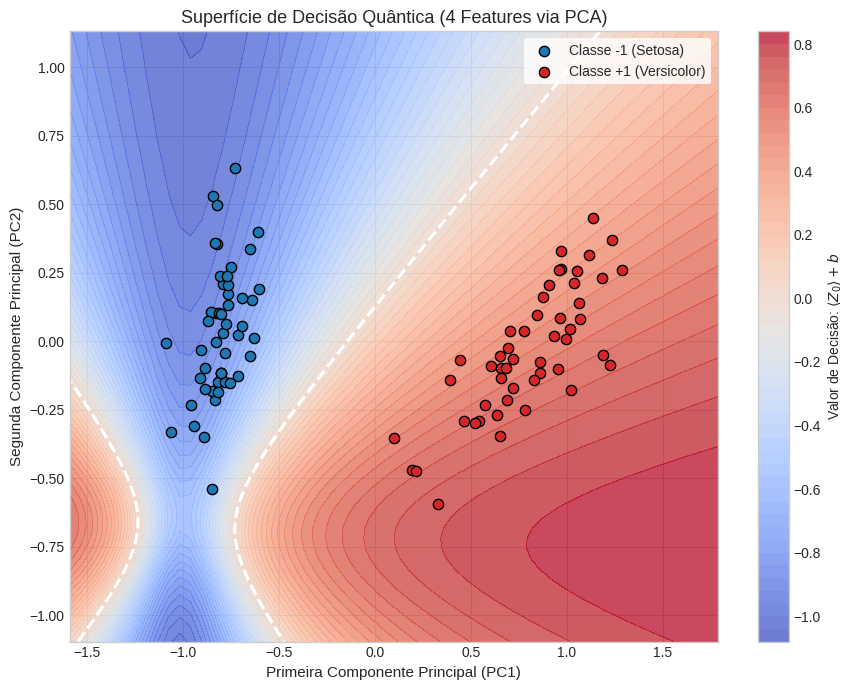

In [20]:
# 7: PLOTAGEM Separando as classes com 4 features usando PCA
plt.style.use("seaborn-v0_8-whitegrid")

# Ajusta o PCA com 2 componentes nas características originais não normalizadas
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Cria a malha regular 2D nos limites dos componentes principais
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 60), np.linspace(y_min, y_max, 60))

# Mapeia a grelha 2D de volta para o espaço 4D para alimentar o circuito quântico
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_4d_approx = pca.inverse_transform(grid_2d)

# Normalização L2 para Amplitude Embedding
grid_norm = grid_4d_approx / np.sqrt(
    np.sum(grid_4d_approx**2, axis=-1, keepdims=True)
)

# Avalia cada ponto pelo classificador quântico
Z = np.array(
    [
        variational_classifier(best_weights, best_bias, pt)
        for pt in grid_norm
    ]
)
Z = Z.reshape(xx.shape)

# plot
plt.figure(figsize=(9, 7))

# Gradiente contínuo com mapa de cores divergente
contour = plt.contourf(xx, yy, Z, levels=50, cmap=cm.coolwarm, alpha=0.75)
plt.colorbar(contour, label=r"Valor de Decisão: $\langle Z_0 \rangle + b$")

# Linha divisória destacada no limiar zero
plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    colors="white",
    linewidths=2.2,
    linestyles="--",
)

# Pontos reais da Classe -1 (Setosa)
plt.scatter(
    X_pca[Y == -1, 0],
    X_pca[Y == -1, 1],
    c="#1f77b4",
    edgecolors="k",
    linewidths=1.0,
    s=55,
    label="Classe -1 (Setosa)",
)

# Pontos reais da Classe +1 (Versicolor)
plt.scatter(
    X_pca[Y == 1, 0],
    X_pca[Y == 1, 1],
    c="#d62728",
    edgecolors="k",
    linewidths=1.0,
    s=55,
    label="Classe +1 (Versicolor)",
)

plt.xlabel("Primeira Componente Principal (PC1)", fontsize=11)
plt.ylabel("Segunda Componente Principal (PC2)", fontsize=11)
plt.title("Superfície de Decisão Quântica (4 Features via PCA)", fontsize=13)
plt.legend(frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()
plt.show()